<a href="https://colab.research.google.com/github/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/blob/main/CIND_820_Notebook_4_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Libraries**

In [29]:
#Check the version of Python being run
!python --version

# Install all dependencies
!pip install pandas matplotlib seaborn ipython numpy vaderSentiment xgboost shap

#Import Libraries
#Data Manipulation, Cleaning, and Analysis
import pandas as pd
import numpy as np
from scipy.stats import skew, shapiro

#Formatting and Visualizations
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from IPython.display import FileLink
from IPython.display import IFrame

#Natural Language Processing (NLP)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

#Modelling and Performance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
import shap

#Timer for models
import time

Python 3.12.13


# **2. Download Listings & Reviews Data from Insideairbnb.com**

In [30]:
#LISTINGS
#Import files
url_toronto = "https://data.insideairbnb.com/canada/on/toronto/2025-11-11/data/listings.csv.gz"
df_toronto = pd.read_csv(url_toronto, compression='gzip')

url_montreal = "https://data.insideairbnb.com/canada/qc/montreal/2025-09-18/data/listings.csv.gz"
df_montreal = pd.read_csv(url_montreal, compression='gzip')

url_ottawa = "https://data.insideairbnb.com/canada/on/ottawa/2025-09-22/data/listings.csv.gz"
df_ottawa = pd.read_csv(url_ottawa, compression='gzip')

#Add city labels
df_toronto['city'] = 'Toronto'
df_montreal['city'] = 'Montreal'
df_ottawa['city'] = 'Ottawa'

#Combine data
df_listings = pd.concat([df_toronto, df_montreal, df_ottawa], ignore_index=True)

#Encode city labels for future modelling
df_listings['city_code'] = df_listings['city'].map({
    'Toronto': 1,
    'Montreal': 2,
    'Ottawa': 3})

#Rename ID to listings_ID to match reviews dataset
df_listings.rename(columns={"id": "listing_id"}, inplace=True)

#REVIEWS
#Import files
url_toronto = "https://data.insideairbnb.com/canada/on/toronto/2025-11-11/data/reviews.csv.gz"
df_toronto_reviews = pd.read_csv(url_toronto, compression='gzip')

url_montreal = "https://data.insideairbnb.com/canada/qc/montreal/2025-09-18/data/reviews.csv.gz"
df_montreal_reviews = pd.read_csv(url_montreal, compression='gzip')

url_ottawa = "https://data.insideairbnb.com/canada/on/ottawa/2025-09-22/data/reviews.csv.gz"
df_ottawa_reviews = pd.read_csv(url_ottawa, compression='gzip')

#Add city labels
df_toronto_reviews['city'] = 'Toronto'
df_montreal_reviews['city'] = 'Montreal'
df_ottawa_reviews['city'] = 'Ottawa'

#Combine data
df_reviews = pd.concat([df_toronto_reviews, df_montreal_reviews, df_ottawa_reviews], ignore_index=True)

#Encode city labels for future modelling
df_reviews['city_code'] = df_reviews['city'].map({
    'Toronto': 1,
    'Montreal': 2,
    'Ottawa': 3})

# **3. Dataset Overview**

In [31]:
#Summarize Listings Data
print(f"""
DATASET OVERVIEW
----------------
Rows: {df_listings.shape[0]:,}
Columns: {df_listings.shape[1]}

FIRST 5 ROWS
---------------""")
display(df_listings.head())

#Summarize Reviews Data
print(f"""
DATASET OVERVIEW
----------------
Rows: {df_reviews.shape[0]:,}
Columns: {df_reviews.shape[1]}

FIRST 5 ROWS
---------------""")
display(df_reviews.head())


DATASET OVERVIEW
----------------
Rows: 33,748
Columns: 81

FIRST 5 ROWS
---------------


,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,city_code
0,1419,https://www.airbnb.com/rooms/1419,20251111064035,2025-11-11,previous scrape,Beautiful home in amazing area!,"This large, family home is located in one of T...",The apartment is located in the Ossington stri...,https://a0.muscache.com/pictures/76206750/d643...,1565,...,5.00,NaN,f,1,1,0,0,0.05,Toronto,1
1,8077,https://www.airbnb.com/rooms/8077,20251111064035,2025-11-11,previous scrape,Downtown Harbourfront Private Room,Guest room in a luxury condo with access to al...,NaN,https://a0.muscache.com/pictures/11780344/141c...,22795,...,4.83,NaN,f,2,1,1,0,0.85,Toronto,1
2,26654,https://www.airbnb.com/rooms/26654,20251111064035,2025-11-11,city scrape,"World Class @ CN Tower, convention centre, The...","CN Tower, TIFF Bell Lightbox, Metro Convention...",There's a reason they call it the Entertainmen...,https://a0.muscache.com/pictures/81811785/5dcd...,113345,...,4.69,NaN,f,3,3,0,0,0.25,Toronto,1
3,27423,https://www.airbnb.com/rooms/27423,20251111064035,2025-11-12,city scrape,Executive Studio Unit- Ideal for One Person,"Brand new, fully furnished studio basement apa...",NaN,https://a0.muscache.com/pictures/176936/b687ed...,118124,...,4.88,NaN,f,1,1,0,0,0.16,Toronto,1
4,30931,https://www.airbnb.com/rooms/30931,20251111064035,2025-11-11,previous scrape,Downtown Toronto - Waterview Condo,Split level waterfront condo with a breathtaki...,NaN,https://a0.muscache.com/pictures/227971/e8ebd7...,22795,...,NaN,NaN,f,2,1,1,0,0.01,Toronto,1



DATASET OVERVIEW
----------------
Rows: 1,195,735
Columns: 8

FIRST 5 ROWS
---------------


,listing_id,id,date,reviewer_id,reviewer_name,comments,city,city_code
0,9974111,105972997,2016-10-03,74630712,Lily,I absolutely loved the location!! I was there ...,Toronto,1
1,9974111,125205050,2017-01-04,23609,Mark,"Stayed here for 2 weeks , great location , gre...",Toronto,1
2,9974111,191232367,2017-09-06,147270253,Dianne,Awesome location! Communication with Shoug was...,Toronto,1
3,9974111,196001139,2017-09-21,5590969,Charie,Had a really great two week stay at Shoug's pl...,Toronto,1
4,9974111,197975881,2017-09-27,76030814,Oswald,great and easy stay - no issues at all,Toronto,1


# **4. Preprocess Datasets According to Findings from Exploratory Data Analysis (EDA)**
  For further analysis, please see the files stored in this directory:
  [Exploratory Data Analysis (EDA)](https://github.com/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/tree/main/Exploratory%20Data%20Analysis%20(EDA))
  
  [Notebook 1 - Automated Exploratory Data Analysis](https://github.com/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/blob/main/Exploratory%20Data%20Analysis%20(EDA)/Notebook%201%20-%20Automated%20Exploratory%20Data%20Analysis%20-%20Data%20Types%2C%20Distributions%2C%20Skewness%2C%20and%20Correlations.ipynb)

  [Notebook 2 - Manual Exploratory Data Analysis](https://github.com/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/blob/main/Exploratory%20Data%20Analysis%20(EDA)/Notebook%202%20-%20Manual%20Exploratory%20Data%20Analysis.ipynb)
  
  [Notebook 3 - Manual Exploratory Data Analysis of Reviews.ipynb](https://github.com/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/blob/main/Exploratory%20Data%20Analysis%20(EDA)/Notebook%203%20-%20Manual%20Exploratory%20Data%20Analysis%20of%20Reviews)

Below we will:
Identify and Handle Features with Large Amount of Missing Values

Data Cleaning: Handle Missing Values in Columns
Data Cleaning: Handle Transformation of Data Types

Manual Feature Selection: Drop Columns Containing Personally Identifiable Information (PII) or not Adding Analytical Value
Manual Feature Selection: Drop Columns with High Cardinality
Feature Selection: Drop Redundant or Features with Low Explanatory Power




# **Handle Features with High Proportion of Missing Values, Transform Data Types, and Perform Feature Selection and Engineering**

In [32]:
#Drop features with >50% Missing values
print ("Missing Values:")
missing = df_listings.isnull().sum()
missing = missing[missing>0]

missing_percent=(missing/len(df_listings))*100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent})

#View only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"]>0]

print ("Drop features with >50% missing values")

columns_to_drop = missing_summary[missing_summary["Missing %"]>50].index
df_listings = df_listings.drop(columns=columns_to_drop)

print(f"""Dropped {len(columns_to_drop)} columns with high missing values.""")
print(f"""Dropped columns: {(columns_to_drop)}""")

#REVIEWS DATA
#Check number of rows with listing IDs in the reviews dataset
print("Listings:", df_listings["listing_id"].nunique())

#Check total number of rows in the reviews dataset
rows_before = len(df_reviews)

#Drop rows with no comments
df_reviews = df_reviews.dropna(subset=["comments"])

#Check number of rows after
rows_after = len(df_reviews)
rows_removed = rows_before - rows_after

print(f"""There are {rows_before:,} rows before dropping blank comments and we remove {rows_removed:,} rows with no comments, leaving {rows_after:,} with at least 1 comment.  """)


#DROPPING FEATURES DUE TO PII, OR LACK OF EXPLANATORY POWER
#LISTINGS DATA
#The columns below will be dropped, due to  PII concerns, low variablity, or in the case of metadata, due to a lack of signifiant value in determining price
more_columns_to_drop = [
    #IDs
    'host_id', 'scrape_id',
    #URLs or Images
    'listing_url', 'host_url', 'picture_url', 'host_thumbnail_url', 'host_picture_url',
    #Text Fields
    'name', 'description', 'neighborhood_overview','host_about', 'amenities',
    #Host Info or PII
    'host_name', 'host_location', 'host_neighbourhood','host_verifications',
    #Metadata
    'last_scraped', 'calendar_last_scraped','calendar_updated', 'source',
    #Redundant Counts to host_listing_counts
    'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms',
    #Redundant to Availability, Estimated Occupancy
    "estimated_occupancy_l365d",
    #Redundant column to City Code, City
    'city',
    #Low Analytical Value due to Low Variability
    'host_has_profile_pic', 'host_identity_verified']

df_listings = df_listings.drop(columns=more_columns_to_drop, errors='ignore')

print (f"""Dropped {len(more_columns_to_drop)} columns representing PII or not adding analytical value in the listings data.""")

#REVIEWS DATA
more_columns_to_drop = [
#Reviewer Info or PII
'reviewer_name',
#Metadata
'date','reviewer_id']

df_reviews = df_reviews.drop(columns=more_columns_to_drop, errors='ignore')
print (f"""Dropped {len(more_columns_to_drop)} columns representing PII or not adding analytical value in the reviews data.""")

#HANDLE MISSING VALUES AND DATA TYPES
#LISTINGS DATA
#NUMBER OF REVIEWS
#Handle missing values in reviews_per_month by imputing 0
df_listings['reviews_per_month'] = df_listings['reviews_per_month'].fillna(0)

#Transform number_of_reviews from string to integer
df_listings['reviews_per_month'] = df_listings['reviews_per_month'].astype(int)

#PRICE
#Transform Price from string to numerical, removing "$ and ," characters
df_listings['price'] = df_listings['price'].replace(r'[\$,]', '', regex=True).astype(float)

#DATES
#Transform dates from string to datetime
df_listings["host_since"] = pd.to_datetime(df_listings["host_since"], errors="coerce")
df_listings["first_review"] = pd.to_datetime(df_listings["first_review"], errors="coerce")
df_listings["last_review"] = pd.to_datetime(df_listings["last_review"], errors="coerce")

#Transform dates to length of years or years since current date, then drop original columns
#Host Since
df_listings["host_year"] = df_listings["host_since"].dt.year
df_listings["years_as_host"] = (pd.Timestamp.today().year- df_listings["host_since"].dt.year)

#Drop the 18 rows missing values for the host year (host join year)
print(f"Drop {df_listings['host_year'].isna().sum()} rows with missing host_year values.")
df_listings = df_listings.dropna(subset=['host_year'])

#First review
df_listings["first_review_year"] = df_listings["first_review"].dt.year
df_listings["years_since_first_review"] = (pd.Timestamp.today().year-df_listings["first_review"].dt.year)

#Last review
df_listings["last_review_year"] = df_listings["last_review"].dt.year
df_listings["years_since_last_review"] = (pd.Timestamp.today().year-df_listings["last_review"].dt.year)

#Drop original or created datetime columns redundantto final years since columns
df_listings.drop(columns=["host_since","host_year", "first_review",'first_review_year', "last_review", "last_review_year"],inplace=True)


#PERCENTAGE RATES COLUMNS
#Transform host_response_rate, host_acceptance_rate from string % to numerical %
df_listings['host_response_rate'] = (df_listings['host_response_rate'].str.replace('%', '').astype(float) / 100)
df_listings['host_acceptance_rate'] = (df_listings['host_acceptance_rate'].str.replace('%', '').astype(float) / 100)

#Fill missing values in host_response & acceptance_rates with 0%, as the host has never replied
df_listings['host_response_rate'] = df_listings['host_response_rate'].fillna(0)
df_listings['host_acceptance_rate'] = df_listings['host_acceptance_rate'].fillna(0)

#BOOLEAN COLUMNS
#Fill missing values in host_is_superhost, has_availability & instant_bookable with False
df_listings['host_is_superhost'] = df_listings['host_is_superhost'].fillna('f')
df_listings['has_availability'] = df_listings['has_availability'].fillna('f')
df_listings['instant_bookable'] = df_listings['instant_bookable'].fillna('f')

#Now convert the True/False boolean columns to 1 or 0:
boolean_columns = ['host_is_superhost','has_availability','instant_bookable']
for col in boolean_columns:df_listings[col] = df_listings[col].map({'t': 1,'f': 0,})

#Check Result of Boolean columns
print(f"""Check Result of Boolean column transformation:
host_is_superhost: {df_listings['host_is_superhost'].unique()}
has_availability: {df_listings['has_availability'].unique()}
instant_bookable: {df_listings['instant_bookable'].unique()}
      """ )

#Transform number of bathrooms from ordinal categorical to numeric (discrete)
#Create new numeric column from bathrooms_text
df_listings['bathrooms_text_to_numeric'] = (df_listings['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float))

#Check Result of Bathrooms
print(f"""Check unique values of transformation from bathroom text to numeric: {df_listings['bathrooms_text_to_numeric'].unique()}""")


#FEATURE SELECTION BY DROPPING REDUNDANT VALUES OR THOSE WITH HIGH CARDINALITY
print(f"""Unique license values will be dropped as there are {df_listings['license'].nunique():,}, among total obseravations of {len(df_listings):,}, which shows high cardinality and low predictive power.""")

extra_cols_to_drop = [

    'beds', #Redundant to accommodates (# of people the property accommodates)
    'host_has_profile_pic', #Low value due to low variance
    'host_identity_verified', #Low value due to low variance

    #Redundant to log-price
    'estimated_revenue_l365d',

    #Redundant to City
    'latitude',
    'longitude',

    #Redundant to overall review_scores_rating
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',

    #Redundant to Availability_365
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_eoy',

    #Redundant to host_listings_count
    'host_total_listings_count',
    'calculated_host_listings_count',

    #Redundant to minimum_nights or maximum_nights
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',

    #Redundant to reviews_per_month
    'number_of_reviews',
    'number_of_reviews_l30d',
    'number_of_reviews_ltm',
    'number_of_reviews_ly',

    #Redundant to bathrooms_text_to_numeric
    'bathrooms',
    'bathrooms_text',

    #Redundant to neighbourhood_cleansed
    'neighbourhood',
    'neighbourhood_group_cleansed',

    #High Cardinality,
    'license']

df_listings = df_listings.drop(columns=extra_cols_to_drop, errors='ignore')

print(f"""
We have dropped the following columns during feature selection, due to their redundancy, low variance, or low explanatory power:
{extra_cols_to_drop}""")

Missing Values:
Drop features with >50% missing values
Dropped 6 columns with high missing values.
Dropped columns: Index(['neighborhood_overview', 'host_about', 'host_neighbourhood',
       'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated'],
      dtype='object')
Listings: 33748
There are 1,195,735 rows before dropping blank comments and we remove 186 rows with no comments, leaving 1,195,549 with at least 1 comment.  
Dropped 27 columns representing PII or not adding analytical value in the listings data.
Dropped 3 columns representing PII or not adding analytical value in the reviews data.
Drop 18 rows with missing host_year values.
Check Result of Boolean column transformation:
host_is_superhost: [0 1]
has_availability: [1 0]
instant_bookable: [0 1]
      
Check unique values of transformation from bathroom text to numeric: [ 3.   1.5  1.   nan  2.   4.   0.   2.5  5.   3.5  4.5  5.5  6.5  6.
 20.   7.   7.5  8.  16.  12.  10.   9. ]
Unique license values will be d

# **8. Handle Missing Values in Price by Missing Dropping Rows, and Skewness in Price by using Log Transformation**

Dropped 7,013 rows missing target variable price

Skewness Value of Price = 32.49

Log transformation is applied to reduce skewness in price.

Check the log transformation:

2    4.897840
3    4.330733
6    4.454347
7    4.584967
8    4.488636
Name: log price, dtype: float64

Log-transformed skewness = 0.57


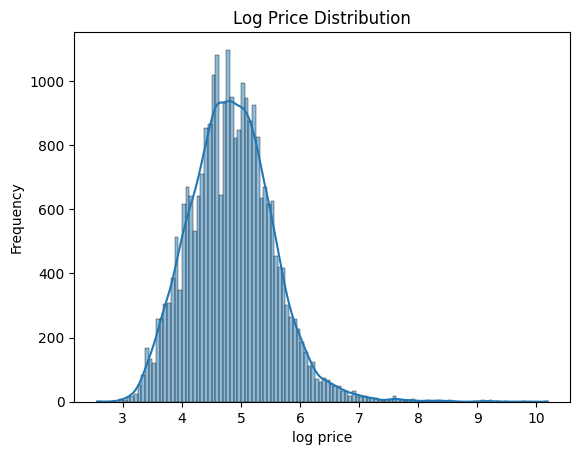

In [33]:
#LISTINGS DATA
#Drop rows in listings data which are missing target variable "price"
missing_prices = df_listings["price"].isna().sum()
print(f"""Dropped {missing_prices:,} rows missing target variable price
""")
df_listings = df_listings.dropna(subset=["price"])

#Check skewness
print(f"""Skewness Value of Price = {df_listings['price'].skew():.2f}

Log transformation is applied to reduce skewness in price.
""")

#Log transform and add to both listings datasets
df_listings['log price'] = np.log1p(df_listings['price'])

#Check results
print("Check the log transformation:\n")
print(df_listings['log price'].head())
print(f"\nLog-transformed skewness = {df_listings['log price'].skew():.2f}")

#Plot Result
sns.histplot(df_listings['log price'], kde=True)
plt.title("Log Price Distribution")
plt.ylabel("Frequency")
plt.show()

# **Check Cardinality of Remaining Categorical Variables which create Dummy Variables in XGBoost Model**

In [34]:
#Check the cardinality of all categorical features, indicating the number of dummy variables created in the XGBoost model
cardinality = pd.DataFrame({
    "Feature": df_listings.select_dtypes(
        include=["object", "category"]).columns, "Unique Values": [df_listings[col].nunique()
        for col in df_listings.select_dtypes(
            include=["object", "category"]).columns]})

display(cardinality.sort_values(by="Unique Values",ascending=False))

,Feature,Unique Values
1,neighbourhood_cleansed,195
2,property_type,65
0,host_response_time,4
3,room_type,4


# **10. Run Sentiment Analysis on Reviews Dataset and Output Sentiment Score per each Review**

In [35]:
#Initialize sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

#Define function, outputting VADER compound sentiment score (-1 to +1)
def get_sentiment(text):
    return analyzer.polarity_scores(str(text))["compound"]

#Apply function and check results
df_reviews["sentiment_score_compound"] = df_reviews["comments"].apply(get_sentiment)
rows_before = len(df_reviews)
display(df_reviews[["comments", "sentiment_score_compound"]].tail())

,comments,sentiment_score_compound
1195730,"Very friendly, very clean & exactly what I was...",0.7930
1195731,As soon as I pulled up there was a bunch of ga...,0.9360
1195732,"Upon checking in, we noticed that the renovati...",-0.5996
1195733,We had an amazing stay at this place. Host was...,0.7430
1195734,"great location, close to airport and highway. ...",0.8016


# **11. Aggregate Multiple Sentiment Scores Across Listings**

Top 5 Rows with Average Sentiment Per Listing and Review Count
      


,listing_id,avg_sentiment,review_count
0,1419,0.927567,6
1,8077,0.904826,167
2,26654,0.802238,45
3,27423,0.910706,31
4,29059,0.691630,499



Total Listings with at least 1 review: 26,520
      


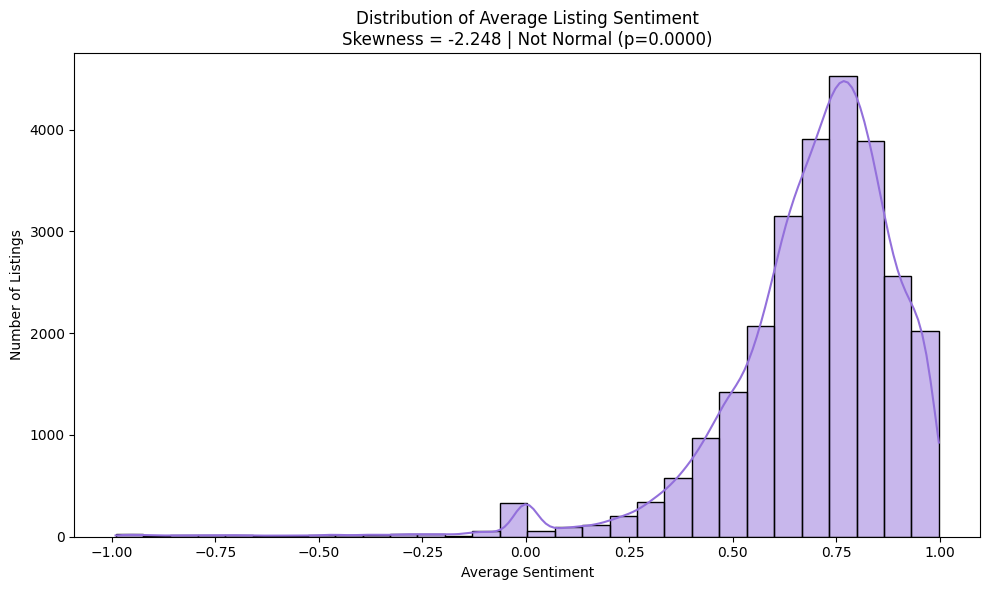

In [36]:
#For each listing, we take the mean of all the review sentiment scores, then count the number of reviews per each listings for volume weighted sentiment
sentiment_per_listing = df_reviews.groupby("listing_id").agg(
    avg_sentiment=("sentiment_score_compound", "mean"),
    review_count=("sentiment_score_compound", "count")).reset_index()

print(f"""Top 5 Rows with Average Sentiment Per Listing and Review Count
      """)
display(sentiment_per_listing.head())

print(f"""
Total Listings with at least 1 review: {len(sentiment_per_listing):,}
      """)

#Show the distribution of average sentiment scores
#Calculate skewness
skewness = skew(sentiment_per_listing["avg_sentiment"])

#Shapiro-Wilk normality test using a sample
stat, p_value = shapiro(
    sentiment_per_listing["avg_sentiment"].sample(
        min(5000, len(sentiment_per_listing)),
        random_state=1))

#Results (Normal Distribution if P>0.05)
normality = "Approximately Normal" if p_value > 0.05 else "Not Normal"

plt.figure(figsize=(10, 6))

sns.histplot(
    sentiment_per_listing["avg_sentiment"],
    bins=30,
    color="mediumpurple",
    kde=True)

plt.title(f"Distribution of Average Listing Sentiment\n"
    f"Skewness = {skewness:.3f} | {normality} (p={p_value:.4f})")

plt.xlabel("Average Sentiment")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

# **12. Get Overall Mean of All Sentiment Scores and Apply Review Volume Based Weighing**

In [37]:
#Calculate mean sentiment score for all listings (range from -1 to 1)
overall_mean_sentiment_score = df_reviews["sentiment_score_compound"].mean()
print(f"""The overall mean sentiment score is {overall_mean_sentiment_score}""")

#Set up the next step, get the median to use as a minimum review count thershold for weighted adjustments
print(f"""
The median at 50% of values is shown below, and will be used as a minmium review count threshold for weighted adjustment:
""")
display(sentiment_per_listing["review_count"].describe())

The overall mean sentiment score is 0.7054250534273373

The median at 50% of values is shown below, and will be used as a minmium review count threshold for weighted adjustment:



,review_count
count,26520.000000
mean,45.081033
std,76.516438
min,1.000000
25%,4.000000
50%,16.000000
75%,53.000000
max,2072.000000


In [38]:
#Apply volume based weighting
#Shrinking the listings with few reviews towards the overall mean sentiment score
#Choose minimum review threshold, set to the median count of reviews of 16
m = 16

sentiment_per_listing["weighted_sentiment"] = ((sentiment_per_listing["review_count"] * sentiment_per_listing["avg_sentiment"] + m * overall_mean_sentiment_score)
    / (sentiment_per_listing["review_count"] + m))

display(sentiment_per_listing[["listing_id", "avg_sentiment", "weighted_sentiment", "review_count"]].head())

,listing_id,avg_sentiment,weighted_sentiment,review_count
0,1419,0.927567,0.766009,6
1,8077,0.904826,0.887392,167
2,26654,0.802238,0.776844,45
3,27423,0.910706,0.840823,31
4,29059,0.691630,0.692059,499


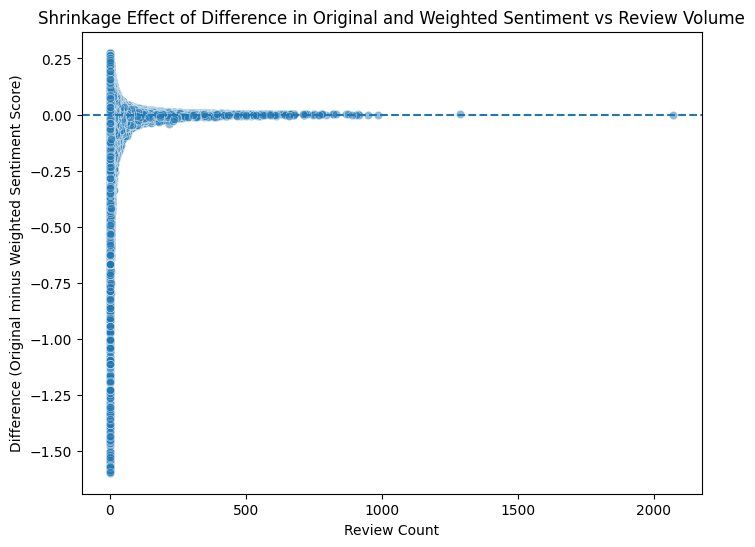

In [39]:
#Show the shrinkage effect after weighing, showing the difference in average sentiment per listing vs weighted sentiment after review count weights are applied
#Left side (low number of reviews) have a big difference, being pulled towards the overall mean
#Right side (high number of reviews) have near zero difference
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sentiment_per_listing,
    x="review_count",
    y=(sentiment_per_listing["avg_sentiment"] - sentiment_per_listing["weighted_sentiment"]),
    alpha=0.5)

plt.axhline(0, linestyle="--")
plt.title("Shrinkage Effect of Difference in Original and Weighted Sentiment vs Review Volume")
plt.xlabel("Review Count")
plt.ylabel("Difference (Original minus Weighted Sentiment Score)")
plt.show()

# **13. Join Sentiment Scores with Listings Data**

In [40]:
#Join the reviews sentiment scores with the preprocessed listings dataset on unique listing id
merged_with_reviews = pd.merge(sentiment_per_listing, df_listings, on="listing_id", how="inner")

#Check merge success
print(f"""The unique weighted sentiment scores are now: {sentiment_per_listing["weighted_sentiment"].unique()}""")
display(merged_with_reviews.head())
display(merged_with_reviews.shape)

print(f"The total number of rows of average weighted sentiments per listing is "f"{len(sentiment_per_listing)}")

#Check the non-matching listing ID rows that were not included in the merged dataset
missing_ids = set(sentiment_per_listing["listing_id"]) - set(df_listings["listing_id"])
print(f"""The missing IDs that received no match are a count of {len(missing_ids)}, and the missing ID is {missing_ids}""")

#Drop listing_id, due to low predictive power
df_listings.drop(columns=["listing_id"], inplace=True, errors="ignore")
merged_with_reviews.drop(columns=["listing_id"], inplace=True, errors="ignore")

The unique weighted sentiment scores are now: [0.76600913 0.88739181 0.77684428 ... 0.72482227 0.72009417 0.70309417]


,listing_id,avg_sentiment,review_count,weighted_sentiment,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,neighbourhood_cleansed,...,has_availability,availability_365,instant_bookable,reviews_per_month,city_code,years_as_host,years_since_first_review,years_since_last_review,bathrooms_text_to_numeric,log price
0,26654,0.802238,45,0.776844,within a few hours,0.91,0.33,1,3.0,Waterfront Communities-The Island,...,1,140,0,0,1,16.0,15.0,1.0,1.0,4.897840
1,27423,0.910706,31,0.840823,NaN,0.00,0.00,0,1.0,South Riverdale,...,1,11,0,0,1,16.0,16.0,1.0,1.0,4.330733
2,29059,0.691630,499,0.692059,within an hour,1.00,1.00,1,2.0,Ville-Marie,...,1,312,0,2,2,16.0,16.0,1.0,1.0,4.905275
3,29061,0.734722,168,0.732174,within an hour,1.00,1.00,1,2.0,Ville-Marie,...,1,332,0,1,2,16.0,14.0,1.0,1.0,5.537334
4,38118,0.740435,17,0.723461,a few days or more,0.00,0.00,0,3.0,Ville-Marie,...,1,322,0,0,2,16.0,15.0,2.0,1.0,3.871201


(21395, 27)

The total number of rows of average weighted sentiments per listing is 26520
The missing IDs that received no match are a count of 5125, and the missing ID is {38731776, 28606469, 950183375861940231, 26083338, 1172802676742029331, 27394074, 902384369065033758, 22020128, 1330627765516468265, 994317118282956848, 719835280402710579, 32931899, 1200151521533755455, 33390655, 690945221656215618, 28835907, 8650822, 1044534380023939147, 21528654, 1262616078478966863, 19824727, 17924185, 51773533, 3833952, 834113478843433057, 701615282269290598, 1426096485831508074, 1000837451637850222, 733357781806809202, 1164070273686831220, 15302793, 1412461075448037513, 26706078, 655522, 14549154, 26640546, 42565798, 968675576570806443, 53772461, 779672066685272238, 10059956, 13238455, 30441660, 5898448, 1339726067990823126, 19693783, 20087006, 1046396390116458729, 36372717, 40009968, 1438487762783666421, 1125594179124691206, 13435146, 1354529426096652556, 1438632983484596492, 1200630229006483728, 42762513,

# **14. Check Correlation of Review Sentiment with Log Adjusted Price**

In [41]:
#Pearson correlation coefficient between weighted sentiment score and price (Airbnb listing price)
correlation = merged_with_reviews["weighted_sentiment"].corr(merged_with_reviews["log price"])
print(f"""The Pearson correlation shows a weak positive correlation
between the weighted sentiment score and log adjusted price of {correlation}""")

The Pearson correlation shows a weak positive correlation
between the weighted sentiment score and log adjusted price of 0.24628894608136379


# **14. Check Correlation of Review Count and Average Sentiment with the new Weighted Sentiment**

 We observe the newly created Weighted Sentiment score does not exhibit high correlation (threshold of >0.8) with Average Sentiment or Review Count, and keep all variables in our model.


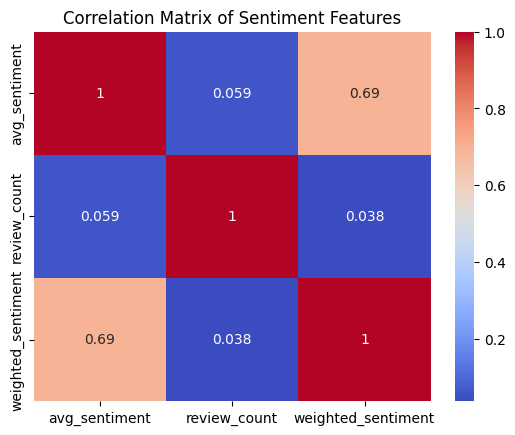

In [42]:
print(f""" We observe the newly created Weighted Sentiment score does not exhibit high correlation (threshold of >0.8) with Average Sentiment or Review Count, and keep all variables in our model.""" )

sns.heatmap(
    merged_with_reviews[
        ['avg_sentiment', 'review_count', 'weighted_sentiment']].corr(),
    annot=True,
    cmap='coolwarm')

plt.title("Correlation Matrix of Sentiment Features")
plt.show()

# **14. Recreate Listings Only Dataset with Same Rows as Listings with Reviews**

In [43]:
#Replace listings dataset
df_listings = merged_with_reviews[
    [col for col in merged_with_reviews.columns if col in df_listings.columns]].copy()

#Check outcome
print(df_listings.shape)
print(merged_with_reviews.shape)

(21395, 23)
(21395, 26)


# **14. Split Datasets into Train and Test, then Impute the Train Set Medians or Modes for Missing Values into Both Train and Test**

In [44]:
def prepare_train_test_split(
    df,
    target='log price',
    test_size=0.2,
    random_state=1):

    #Remove rows with missing target
    df = df.dropna(subset=[target]).copy()

    #Target
    y = df[target]

    # Features (remove target of log price and original price)
    X = df.drop(columns=[target, 'price'], errors='ignore')

    # Train/Test Split FIRST
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state)

    #Impute median from training dataset into both train and test datasets, for numerical features missing values
    numeric_median_cols = ['host_listings_count',
        'bedrooms',
        'bathrooms_text_to_numeric',
        'years_since_first_review',
        'years_since_last_review']

    numeric_median_cols = [
        col for col in numeric_median_cols
        if col in X_train.columns]

    train_medians = X_train[numeric_median_cols].median()

    X_train[numeric_median_cols] = (
        X_train[numeric_median_cols]
        .fillna(train_medians))

    X_test[numeric_median_cols] = (
        X_test[numeric_median_cols]
        .fillna(train_medians))

    #Impute mode from the train set into both train and test, for numerical features missing values
    categorical_mode_cols = ['host_response_time' ]

    categorical_mode_cols = [
        col for col in categorical_mode_cols
        if col in X_train.columns]

    for col in categorical_mode_cols:
        train_mode = X_train[col].mode()
        if len(train_mode) > 0:
            mode_value = train_mode.iloc[0]
            X_train[col] = X_train[col].fillna(mode_value)
            X_test[col] = X_test[col].fillna(mode_value)

    return X_train, X_test, y_train, y_test

# **Check the Results of Train-Test Split and Imputation using Train Median/Mode on both Listings & Listings + Reviews Datasets**

In [45]:
# Listings only dataset
X_train_listings, X_test_listings, y_train_listings, y_test_listings = (
    prepare_train_test_split(df_listings))

# Listings + Reviews dataset
X_train_reviews, X_test_reviews, y_train_reviews, y_test_reviews = (
    prepare_train_test_split(merged_with_reviews))

#CHECK RESULTS
print("LISTINGS DATASET")
print("X_train:", X_train_listings.shape)
print("X_test :", X_test_listings.shape)
print("y_train:", y_train_listings.shape)
print("y_test :", y_test_listings.shape)

print("\nLISTINGS + REVIEWS DATASET")
print("X_train:", X_train_reviews.shape)
print("X_test :", X_test_reviews.shape)
print("y_train:", y_train_reviews.shape)
print("y_test :", y_test_reviews.shape)

LISTINGS DATASET
X_train: (17116, 21)
X_test : (4279, 21)
y_train: (17116,)
y_test : (4279,)

LISTINGS + REVIEWS DATASET
X_train: (17116, 24)
X_test : (4279, 24)
y_train: (17116,)
y_test : (4279,)


# **16. Create a K-Fold Cross Validation procedure for Training Data using Simple Linear Regression**


In [46]:
#K-Fold Cross Validation for Linear Regression Baseline model
def linear_regression_cv(
    X_train,
    y_train,
    n_splits=5,
    random_state=1):

    # Encode categoricals
    X_train = pd.get_dummies(X_train, drop_first=True)

    cv = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state)

    lr = LinearRegression()

    scores = cross_validate(
        lr,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "r2",
            "neg_mean_absolute_percentage_error",
            "neg_root_mean_squared_error"])

    results = pd.DataFrame({
        "Metric": ["R²", "MAPE", "RMSE"],
        "Mean CV Score": [
            scores["test_r2"].mean(),
            -scores["test_neg_mean_absolute_percentage_error"].mean(),
            -scores["test_neg_root_mean_squared_error"].mean()],
        "Std Dev CV R²": [scores["test_r2"].std(), np.nan, np.nan]})

    return results.round(4)

# **16. Create K-Fold Cross Validation for Random Forest**

In [47]:
#K-Fold Cross Validation for Random Forest
def random_forest_cv(
    X_train,
    y_train,
    n_splits=5,
    random_state=1):

    #Encode categoricals
    X_train = pd.get_dummies(X_train, drop_first=True)

    cv = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state)

    rf = RandomForestRegressor(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1)

    scores = cross_validate(
        rf,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "r2",
            "neg_mean_absolute_percentage_error",
            "neg_root_mean_squared_error"])

    results = pd.DataFrame({
        "Metric": ["R²", "MAPE", "RMSE"],
        "Mean CV Score": [
            scores["test_r2"].mean(),
            -scores["test_neg_mean_absolute_percentage_error"].mean(),
            -scores["test_neg_root_mean_squared_error"].mean()],
        "Std Dev CV R²": [
            scores["test_r2"].std(),
            np.nan,
            np.nan]})
    return results.round(4)

# **16. Create K-Fold Cross Validation for XGBoost**

In [48]:
#K-Fold Cross Validation for XGBoost
def xgboost_cv(
    X_train,
    y_train,
    n_splits=5,
    random_state=1):

    # Encode categoricals
    X_train = pd.get_dummies(X_train, drop_first=True)

    cv = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state)

    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1)

    scores = cross_validate(
        xgb,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "r2",
            "neg_mean_absolute_percentage_error",
            "neg_root_mean_squared_error"])

    results = pd.DataFrame({
        "Metric": ["R²", "MAPE", "RMSE"],
        "Mean CV Score": [
            scores["test_r2"].mean(),
            -scores["test_neg_mean_absolute_percentage_error"].mean(),
            -scores["test_neg_root_mean_squared_error"].mean()
        ],
        "Std Dev CV R²": [
            scores["test_r2"].std(),
            np.nan,
            np.nan
        ]})

    return results.round(4)

# **16. Create a Simple Linear Regression Model to Compare Benchmark Performance**

In [49]:
def linear_regression_baseline(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name="Dataset"):

    #Encode categorical variables
    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)

    #Ensure train and test have same columns after creating dummy variables
    X_train, X_test = X_train.align(
        X_test,
        join="left",
        axis=1,
        fill_value=0)

    #Train model
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    #Predict
    y_pred = lr.predict(X_test)

    #Metrics
    results = pd.DataFrame({
        "Dataset": [dataset_name],
        "Model": ["Linear Regression"],
        "R²": [r2_score(y_test, y_pred)],
        "MAPE": [mean_absolute_percentage_error(y_test, y_pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred))]})

    return results.round(4)

# **15. Create Random Forest Model to Predict Log Price on Listings Dataset vs Listings Dataset with Review Sentiment Scores**

In [50]:
#Random Forest Function
def random_forest(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name="Dataset",
    random_state=1):

    total_start = time.time()

    # One-hot encode categorical variables
    encoding_start = time.time()

    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)

    # Ensure train and test have identical columns
    X_train, X_test = X_train.align(
        X_test,
        join="left",
        axis=1,
        fill_value=0)

    encoding_end = time.time()

    #Leakage checks for price and log price
    print(f"\nTrain shape after encoding: {X_train.shape}")
    print(f"Test shape after encoding: {X_test.shape}")

    print([
          col for col in X_train.columns
          if "price" in col.lower()])

    print("log price in X_train:", "log price" in X_train.columns)
    print("price in X_train:", "price" in X_train.columns)

    print("log price in X_test:", "log price" in X_test.columns)
    print("price in X_test:", "price" in X_test.columns)

    #Build model
    rf = RandomForestRegressor(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1)

    #Train
    train_start = time.time()

    rf.fit(X_train, y_train)

    train_end = time.time()

    # Predict
    predict_start = time.time()

    predictions = rf.predict(X_test)

    predict_end = time.time()
    total_end = time.time()

    #Feature importance
    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_}).sort_values("Importance",ascending=False)

    #Timing report
    print(f"\nEncoding Time: {encoding_end - encoding_start:.2f} sec")
    print(f"Training Time: {train_end - train_start:.2f} sec")
    print(f"Prediction Time: {predict_end - predict_start:.2f} sec")
    print(f"Total Runtime: {total_end - total_start:.2f} sec")

    metrics = pd.DataFrame({
        "Dataset": [dataset_name],
        "Model": ["Random Forest"],
        "R²": [r2_score(y_test, predictions)],
        "MAPE": [mean_absolute_percentage_error(y_test, predictions)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, predictions))]})

    return metrics.round(4), feature_importance

# **16. Create XGBoost Model to Predict Log Price on Listings Dataset vs Listings Dataset with Review Sentiment Scores**

In [51]:
# Create the function to run XGBoost
def xgboost_model(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name="Dataset",
    random_state=1):

    total_start = time.time()

    # One-hot encode categorical variables
    encoding_start = time.time()

    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)

    # Ensure train and test have same columns after dummy encoding
    X_train, X_test = X_train.align(
        X_test,
        join="left",
        axis=1,
        fill_value=0)

    encoding_end = time.time()

   #Leakage checks for price and log price
    print(f"\nTrain shape after encoding: {X_train.shape}")
    print(f"Test shape after encoding: {X_test.shape}")

    print([
          col for col in X_train.columns
          if "price" in col.lower()])

    print("log price in X_train:", "log price" in X_train.columns)
    print("price in X_train:", "price" in X_train.columns)

    print("log price in X_test:", "log price" in X_test.columns)
    print("price in X_test:", "price" in X_test.columns)

    # Build model
    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1)

    #Train model
    train_start = time.time()

    xgb.fit(X_train, y_train)

    train_end = time.time()

    #Predict
    predict_start = time.time()

    predictions = xgb.predict(X_test)

    predict_end = time.time()
    total_end = time.time()

    #Feature importance dataframe
    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": xgb.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    #Timing Report
    print(f"\nEncoding Time: {encoding_end - encoding_start:.2f} sec")
    print(f"Training Time: {train_end - train_start:.2f} sec")
    print(f"Prediction Time: {predict_end - predict_start:.2f} sec")
    print(f"Total Runtime: {total_end - total_start:.2f} sec")

    metrics = pd.DataFrame({
        "Dataset": [dataset_name],
        "Model": ["XGBoost"],
        "R²": [r2_score(y_test, predictions)],
        "MAPE": [mean_absolute_percentage_error(y_test, predictions)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, predictions))]})

    return (metrics.round(4),
        feature_importance,
        xgb,
        X_test)

# **16. Run K-Fold Cross Validation for All models on only Listings Dataset with Review Sentiment Scores**

In [52]:
#LINEAR REGRESSION K-FOLD
lr_cv_reviews = linear_regression_cv(
    X_train_reviews,
    y_train_reviews)

#RANDOM FOREST K-FOLD
#Run K-Fold Cross Validations on Listings + Reviews
rf_cv_reviews = random_forest_cv(
    X_train_reviews,
    y_train_reviews)

#XGBOOST K-FOLD ON Listings + Reviews
xgb_cv_reviews = xgboost_cv(
    X_train_reviews,
    y_train_reviews)

,Metric,Mean CV Score,Std Dev CV R²
0,R²,0.6377,0.0208
1,MAPE,0.0641,NaN
2,RMSE,0.4173,NaN


# **16. Run the Linear Regression for Benchmark Performance**

In [53]:
lr_listings = linear_regression_baseline(
    X_train_listings,
    X_test_listings,
    y_train_listings,
    y_test_listings,
    dataset_name="Listings Only")

lr_reviews = linear_regression_baseline(
    X_train_reviews,
    X_test_reviews,
    y_train_reviews,
    y_test_reviews,
    dataset_name="Listings + Reviews")

display(pd.concat([lr_listings, lr_reviews]))

,Dataset,Model,R²,MAPE,RMSE
0,Listings Only,Linear Regression,0.5833,0.0673,0.4517
0,Listings + Reviews,Linear Regression,0.5942,0.0663,0.4457


# **17. Run Random Forest Model Predicting Log Price for Listings Dataset vs Listings Dataset with Review Sentiment Scores**

In [54]:
#RANDOM FOREST
#Listings model
rf_listings_metrics, rf_listings_importance = random_forest(
    X_train_listings,
    X_test_listings,
    y_train_listings,
    y_test_listings,
    dataset_name="Listings Only")

# Reviews model
rf_reviews_metrics, rf_reviews_importance = random_forest(
    X_train_reviews,
    X_test_reviews,
    y_train_reviews,
    y_test_reviews,
    dataset_name="Listings + Reviews")


Train shape after encoding: (17116, 271)
Test shape after encoding: (4279, 271)
[]
log price in X_train: False
price in X_train: False
log price in X_test: False
price in X_test: False

Encoding Time: 0.07 sec
Training Time: 79.44 sec
Prediction Time: 0.56 sec
Total Runtime: 80.07 sec

Train shape after encoding: (17116, 274)
Test shape after encoding: (4279, 274)
[]
log price in X_train: False
price in X_train: False
log price in X_test: False
price in X_test: False

Encoding Time: 0.03 sec
Training Time: 85.81 sec
Prediction Time: 0.31 sec
Total Runtime: 86.15 sec


# **17. Run XGBoost Model Predicting Log Price for Listings Dataset vs Listings Dataset with Review Sentiment Scores**

In [55]:
#XGBOOST
#Listings model
xgb_listings_metrics, xgb_listings_importance, xgb_listings_model, xgb_listings_test = (
    xgboost_model(
        X_train_listings,
        X_test_listings,
        y_train_listings,
        y_test_listings,
        dataset_name="Listings Only"))

#Reviews model
xgb_reviews_metrics, xgb_reviews_importance, xgb_reviews_model, xgb_reviews_test = (
    xgboost_model(
        X_train_reviews,
        X_test_reviews,
        y_train_reviews,
        y_test_reviews,
        dataset_name="Listings + Reviews"))


Train shape after encoding: (17116, 271)
Test shape after encoding: (4279, 271)
[]
log price in X_train: False
price in X_train: False
log price in X_test: False
price in X_test: False

Encoding Time: 0.03 sec
Training Time: 2.26 sec
Prediction Time: 0.07 sec
Total Runtime: 2.36 sec

Train shape after encoding: (17116, 274)
Test shape after encoding: (4279, 274)
[]
log price in X_train: False
price in X_train: False
log price in X_test: False
price in X_test: False

Encoding Time: 0.03 sec
Training Time: 2.35 sec
Prediction Time: 0.10 sec
Total Runtime: 2.49 sec


# **18. Show Performance Metrics for K-Fold Cross Validation of Linear Regression, Random Forest, and XGBoost Models**

In [56]:
#All Results from K-Fold Cross Validation
#Label Models
lr_cv_reviews.insert(1, "Model", "Linear Regression")
rf_cv_reviews.insert(1, "Model", "Random Forest")
xgb_cv_reviews.insert(1, "Model", "XGBoost")

#Display Combined Results
cv_results = pd.concat([
    lr_cv_reviews,
    rf_cv_reviews,
    xgb_cv_reviews],
    ignore_index=True)

display(cv_results)

,Metric,Model,Mean CV Score,Std Dev CV R²
0,R²,Linear Regression,0.6377,0.0208
1,MAPE,Linear Regression,0.0641,NaN
2,RMSE,Linear Regression,0.4173,NaN
3,R²,Random Forest,0.6985,0.0234
4,MAPE,Random Forest,0.0558,NaN
5,RMSE,Random Forest,0.3806,NaN
6,R²,XGBoost,0.7169,0.0187
7,MAPE,XGBoost,0.0549,NaN
8,RMSE,XGBoost,0.3689,NaN


# **18. Show Performance Metrics for Linear Regression, Random Forest, and XGBoost Models**

In [57]:
all_results = pd.concat([
    lr_listings,
    lr_reviews,
    rf_listings_metrics,
    rf_reviews_metrics,
    xgb_listings_metrics,
    xgb_reviews_metrics], ignore_index=True)

display(all_results)

,Dataset,Model,R²,MAPE,RMSE
0,Listings Only,Linear Regression,0.5833,0.0673,0.4517
1,Listings + Reviews,Linear Regression,0.5942,0.0663,0.4457
2,Listings Only,Random Forest,0.6907,0.0549,0.3891
3,Listings + Reviews,Random Forest,0.6894,0.0560,0.3899
4,Listings Only,XGBoost,0.6878,0.0566,0.3909
5,Listings + Reviews,XGBoost,0.6988,0.0557,0.3840


# **19. Show Top 20 Features for Random Forest abd XGBoost Models**

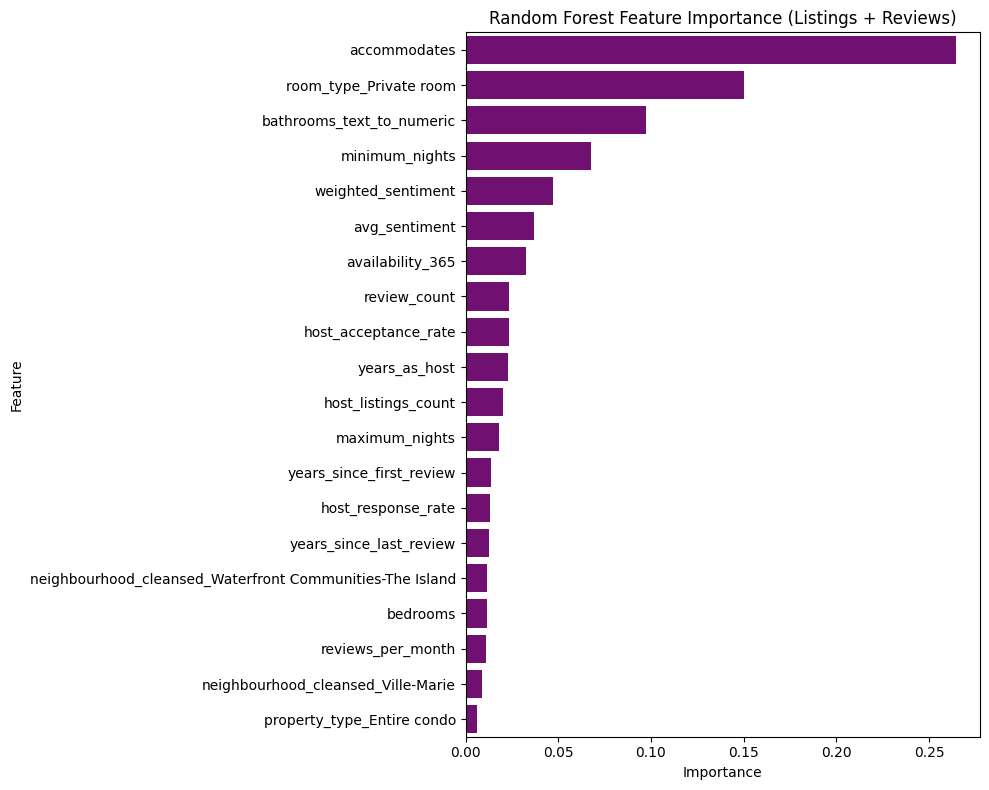

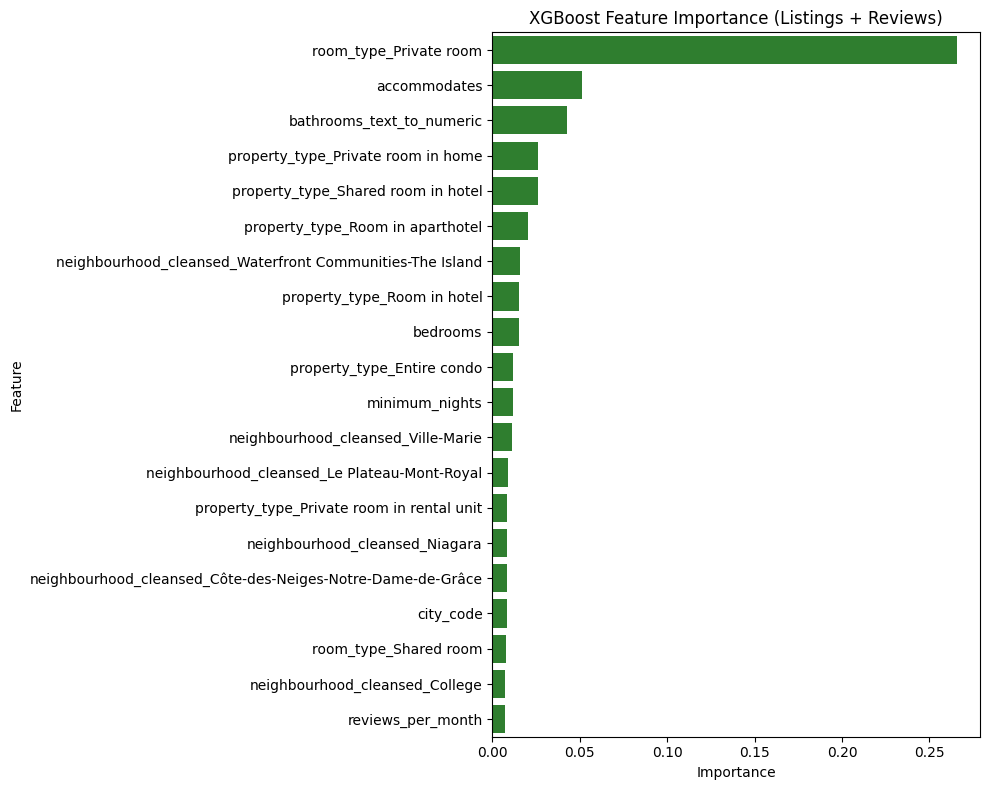

In [58]:
#Random Forest - Listings + Reviews

top_rf = rf_reviews_importance.head(20).sort_values(
    by="Importance",
    ascending=False)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_rf,
    x="Importance",
    y="Feature",
    color="purple")

plt.title("Random Forest Feature Importance (Listings + Reviews)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


#XGBoost - Listings + Reviews
top_xgb = xgb_reviews_importance.head(20).sort_values(
    by="Importance",
    ascending=False)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_xgb,
    x="Importance",
    y="Feature",
   color="forestgreen")

plt.title("XGBoost Feature Importance (Listings + Reviews)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# **18. Show SHAP Feature Importance Plot for XGBoost Model Only**

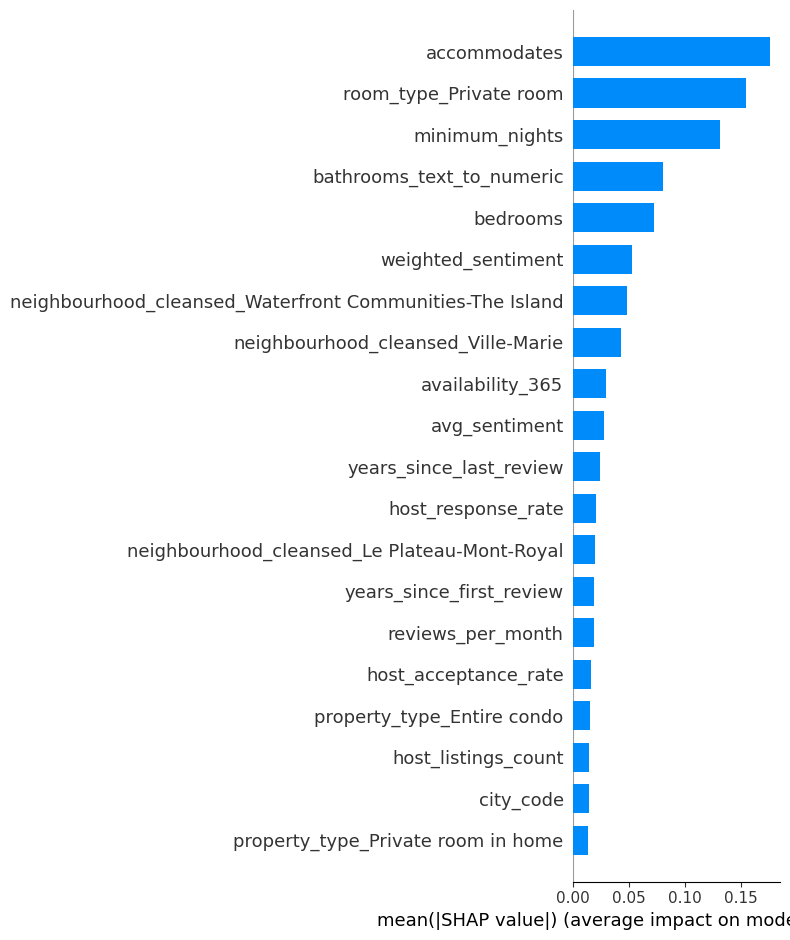

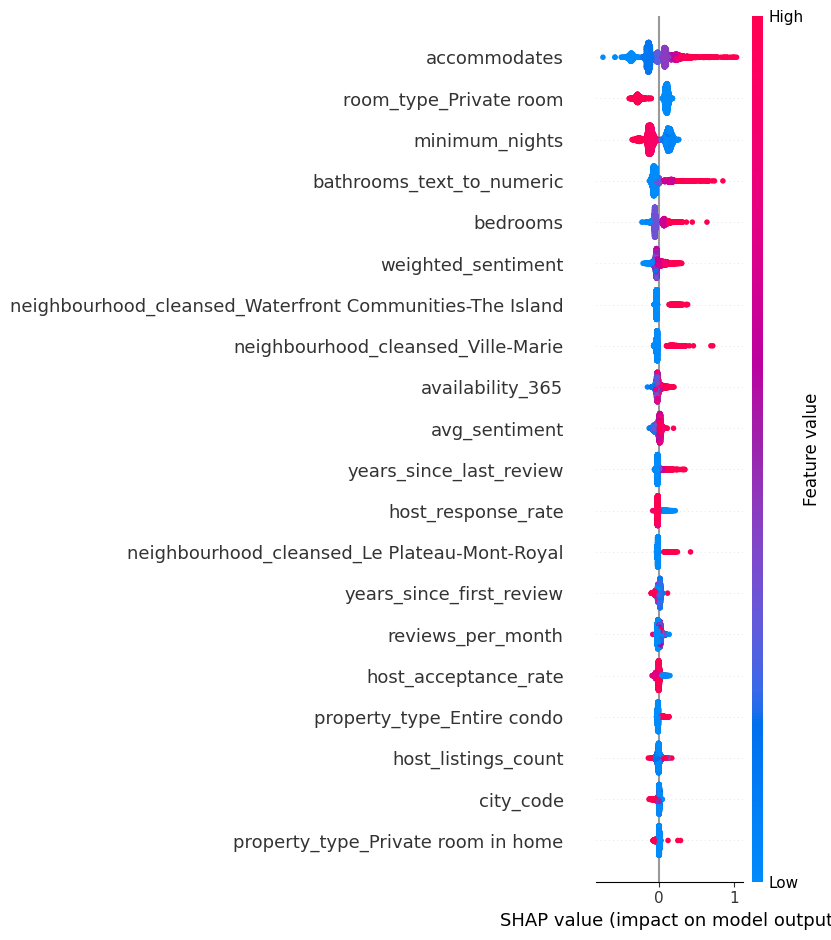

In [59]:
#XGBoost SHAP Importance Plot
#Create SHAP explainer using XGBoost Model
explainer = shap.TreeExplainer(xgb_reviews_model)

#Calculate SHAP values
shap_values = explainer.shap_values(xgb_reviews_test)

#SHAP Feature Importance Plot
shap.summary_plot(shap_values, xgb_reviews_test, plot_type="bar")

#SHAP Bar Plot
shap.summary_plot(shap_values, xgb_reviews_test)